# Experiment 4: Statistical Hypothesis Testing Using Python

## Mapped CO(s): CO2

### **Aim:**
To perform statistical hypothesis testing on the Titanic dataset using Python and interpret the results using p-values.

### **Objectives:**
1. To understand the concept of hypothesis testing.
2. To formulate null and alternative hypotheses.
3. To perform statistical tests using Python.
4. To interpret p-values and significance levels.
5. To draw conclusions based on the test results.

### **Prerequisites:**
- Basic knowledge of Python programming.
- Basic understanding of probability and statistics.
- Python 3.x installed.
- Jupyter Notebook or Google Colab.
- Required libraries: Pandas, NumPy, SciPy, Matplotlib, and Seaborn.

---

### **Theory/Background**
**Statistical Hypothesis Testing** is a method used to determine whether there is sufficient evidence to support a claim about a population based on sample data.

A hypothesis test consists of two hypotheses:
- **Null Hypothesis ($H_0$):** Assumes there is no significant difference or relationship between variables.
- **Alternative Hypothesis ($H_1$):** Assumes there is a significant difference or relationship between variables.

The **p-value** is compared with the significance level ($lpha = 0.05$):
- If **p-value < 0.05**, reject the null hypothesis (statistically significant difference).
- If **p-value $\ge$ 0.05**, fail to reject the null hypothesis (no statistically significant difference).

In this experiment, an **Independent Sample t-test** is performed to determine whether the average age of passengers differs significantly based on survival status.

## **Step 1: Import Required Python Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## **Step 2: Load the Titanic Dataset**

In [2]:
# Load the Titanic dataset from Seaborn
df = sns.load_dataset('titanic')
print(f"Original dataset shape: {df.shape}")
df.head()

Original dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## **Step 3: Select Required Variables and Clean Missing Values**
We focus on the `age` and `survived` attributes. We check for missing values in the `age` column and drop any rows containing missing values.

In [3]:
# Check for missing values in age and survived
print("Missing values:")
print(df[['age', 'survived']].isnull().sum())

# Clean missing values by dropping rows where age is missing
df_clean = df[['age', 'survived']].dropna()
print(f"\nCleaned dataset shape: {df_clean.shape}")
df_clean.head()

Missing values:
age         177
survived      0
dtype: int64

Cleaned dataset shape: (714, 2)


,age,survived
0,22.0,0
1,38.0,1
2,26.0,1
3,35.0,1
4,35.0,0


## **Step 4: Separate Passengers into Survived and Not Survived Groups**

In [4]:
# Separate groups
age_survived = df_clean[df_clean['survived'] == 1]['age']
age_not_survived = df_clean[df_clean['survived'] == 0]['age']

# Calculate and display descriptive statistics
print(f"Number of survivors with age data: {len(age_survived)}")
print(f"Mean age of survivors: {age_survived.mean():.4f} years")
print(f"Standard deviation of survivors' age: {age_survived.std():.4f} years\n")

print(f"Number of non-survivors with age data: {len(age_not_survived)}")
print(f"Mean age of non-survivors: {age_not_survived.mean():.4f} years")
print(f"Standard deviation of non-survivors' age: {age_not_survived.std():.4f} years")

Number of survivors with age data: 290
Mean age of survivors: 28.3437 years
Standard deviation of survivors' age: 14.9510 years

Number of non-survivors with age data: 424
Mean age of non-survivors: 30.6262 years
Standard deviation of non-survivors' age: 14.1721 years


## **Step 5: Perform the Independent Sample t-test using SciPy**
We formulate the hypotheses:
- **Null Hypothesis ($H_0$):** There is no significant difference in the average age of passengers who survived and those who did not survive ($\mu_{survived} = \mu_{not\_survived}$).
- **Alternative Hypothesis ($H_1$):** There is a significant difference in the average age of passengers who survived and those who did not survive ($\mu_{survived} \neq \mu_{not\_survived}$).

In [5]:
# Perform t-test assuming equal variances
t_stat, p_val = stats.ttest_ind(age_survived, age_not_survived, equal_var=True)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

t-statistic: -2.0667
p-value: 0.0391


## **Step 6: Visualizing the Data**
We visualize the age distributions using a combination of a boxplot and a KDE plot to understand the visual difference between the two groups.

C:\Users\Jeetu Mehra\AppData\Local\Temp\ipykernel_31948\3640563340.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='survived', y='age', palette='Set1', ax=axes[1])


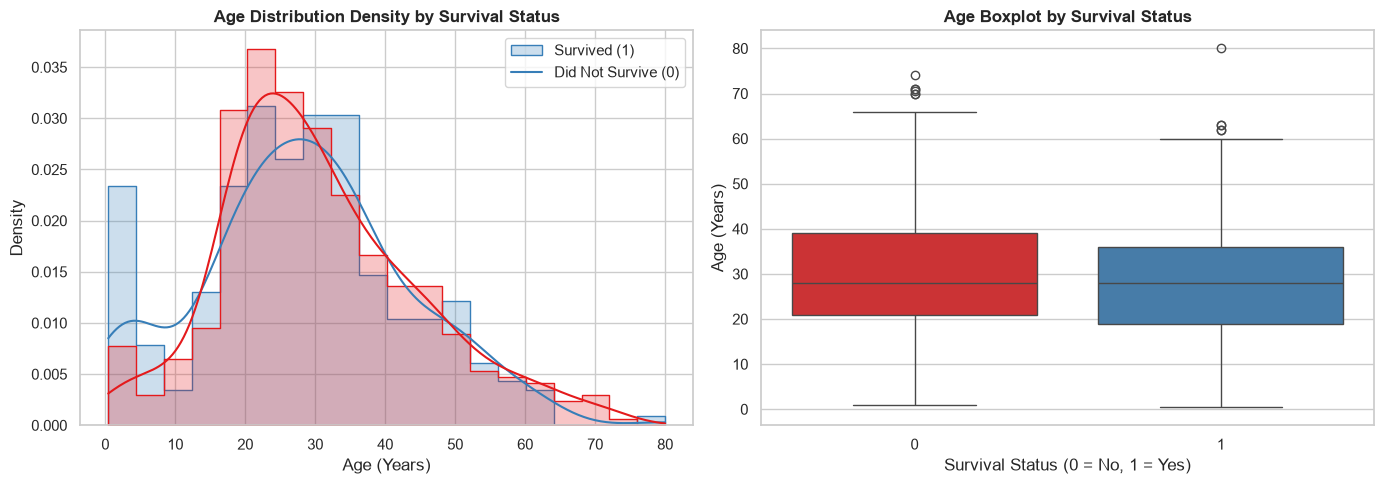

In [6]:
# Plotting age distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE Plot
sns.histplot(data=df_clean, x='age', hue='survived', kde=True, element='step', stat='density', common_norm=False, palette='Set1', ax=axes[0])
axes[0].set_title('Age Distribution Density by Survival Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Density')
axes[0].legend(labels=['Survived (1)', 'Did Not Survive (0)'])

# Box Plot
sns.boxplot(data=df_clean, x='survived', y='age', palette='Set1', ax=axes[1])
axes[1].set_title('Age Boxplot by Survival Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Survival Status (0 = No, 1 = Yes)')
axes[1].set_ylabel('Age (Years)')

plt.tight_layout()
plt.show()

## **Step 7: Interpret the Hypothesis Test Result**

In [7]:
alpha = 0.05
print(f"Significance Level (alpha): {alpha}")
print(f"Obtained p-value: {p_val:.4f}")

if p_val < alpha:
    print("Conclusion: Reject the Null Hypothesis (H0). There is a statistically significant difference in the average age of survivors versus non-survivors.")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis (H0). There is no statistically significant difference in the average age of survivors versus non-survivors.")

Significance Level (alpha): 0.05
Obtained p-value: 0.0391
Conclusion: Reject the Null Hypothesis (H0). There is a statistically significant difference in the average age of survivors versus non-survivors.


--- 
# **Exercises/Assignments**

### **Exercise 1: Perform a t-test using the Fare variable instead of Age**
- **Null Hypothesis ($H_0$):** There is no significant difference in the average ticket fare of passengers who survived and those who did not survive ($\mu_{survived} = \mu_{not\_survived}$).
- **Alternative Hypothesis ($H_1$):** There is a significant difference in the average ticket fare of passengers who survived and those who did not survive ($\mu_{survived} \neq \mu_{not\_survived}$).

In [8]:
# Select fare and survived variables and drop missing values
df_fare = df[['fare', 'survived']].dropna()
print(f"Cleaned fare dataset shape: {df_fare.shape}")

# Separate groups
fare_survived = df_fare[df_fare['survived'] == 1]['fare']
fare_not_survived = df_fare[df_fare['survived'] == 0]['fare']

print(f"Mean fare of survived: ${fare_survived.mean():.4f}")
print(f"Mean fare of not survived: ${fare_not_survived.mean():.4f}\n")

# Perform independent t-test (equal_var=False because variances in fare are likely very unequal)
t_stat_fare, p_val_fare = stats.ttest_ind(fare_survived, fare_not_survived, equal_var=False)
print(f"t-statistic (unequal variance t-test): {t_stat_fare:.4f}")
print(f"p-value: {p_val_fare:.4g}")

Cleaned fare dataset shape: (891, 2)
Mean fare of survived: $48.3954
Mean fare of not survived: $22.1179

t-statistic (unequal variance t-test): 6.8391
p-value: 2.699e-11


### **Exercise 2 & 3: Change the significance level from 0.05 to 0.01 and compare/interpret the results**

C:\Users\Jeetu Mehra\AppData\Local\Temp\ipykernel_31948\935004529.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_fare, x='survived', y='fare', palette='Set2')


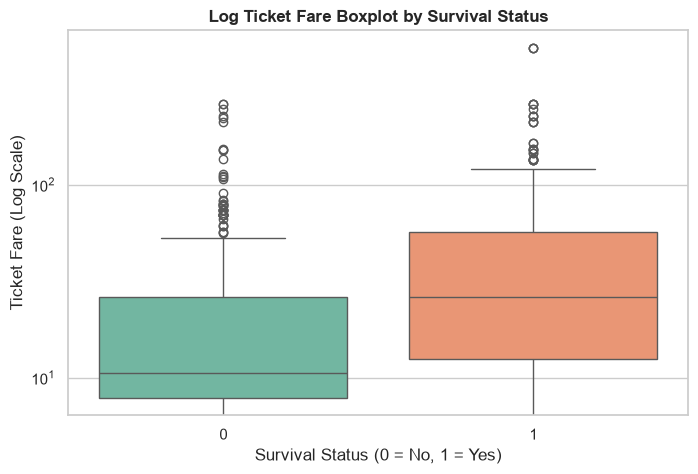

New Significance Level (alpha): 0.01
Obtained p-value for Fare: 2.699e-11

Conclusion at alpha=0.01: Reject the Null Hypothesis (H0). The difference in mean ticket fare between survivors and non-survivors is highly significant.


In [9]:
# Visualizing fare distributions
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_fare, x='survived', y='fare', palette='Set2')
plt.yscale('log') # use log scale because fares are highly skewed
plt.title('Log Ticket Fare Boxplot by Survival Status', fontsize=12, fontweight='bold')
plt.xlabel('Survival Status (0 = No, 1 = Yes)')
plt.ylabel('Ticket Fare (Log Scale)')
plt.show()

# Interpretation for Significance Level Comparison
alpha_new = 0.01
print(f"New Significance Level (alpha): {alpha_new}")
print(f"Obtained p-value for Fare: {p_val_fare:.4g}")

if p_val_fare < alpha_new:
    print("\nConclusion at alpha=0.01: Reject the Null Hypothesis (H0). The difference in mean ticket fare between survivors and non-survivors is highly significant.")
else:
    print("\nConclusion at alpha=0.01: Fail to Reject the Null Hypothesis (H0).")

### **Exercise 4: Apply another statistical test such as the Chi-Square test**
We will test whether there is a statistically significant association between survival status (`survived`) and passenger class (`pclass`).
- **Null Hypothesis ($H_0$):** Survival status and passenger class are independent (no association).
- **Alternative Hypothesis ($H_1$):** Survival status and passenger class are associated (a passenger's class affects their survival probability).

Contingency Table (Observed Frequencies):
pclass      1   2    3
survived              
0          80  97  372
1         136  87  119


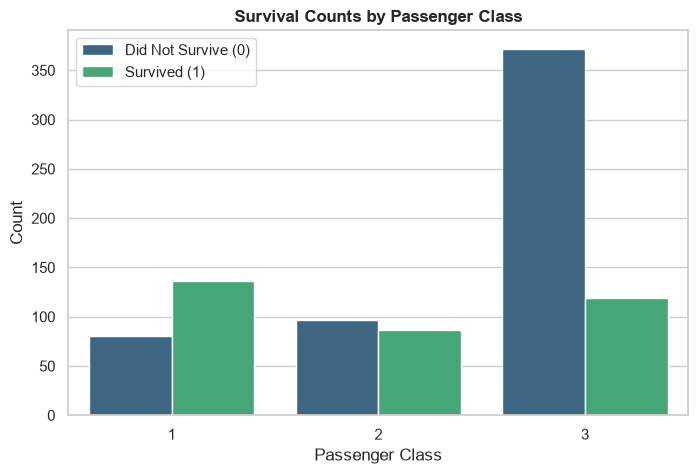

Chi-Square Statistic: 102.8890
Degrees of Freedom: 2
p-value: 4.549e-23

Expected Frequencies (under the Null Hypothesis):
            Class 1  Class 2  Class 3
survived=0   133.09   113.37   302.54
survived=1    82.91    70.63   188.46

Since p-value (4.549e-23) < alpha (0.05), we reject the Null Hypothesis (H0). Survival status is significantly associated with passenger class.


In [10]:
# Create a contingency table
contingency_table = pd.crosstab(df['survived'], df['pclass'])
print("Contingency Table (Observed Frequencies):")
print(contingency_table)

# Plot survival count by passenger class
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='pclass', hue='survived', palette='viridis')
plt.title('Survival Counts by Passenger Class', fontsize=12, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(labels=['Did Not Survive (0)', 'Survived (1)'])
plt.show()

# Perform the Chi-Square Test of Independence
chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"p-value: {p_val_chi2:.4g}\n")

print("Expected Frequencies (under the Null Hypothesis):")
print(pd.DataFrame(expected, index=['survived=0', 'survived=1'], columns=['Class 1', 'Class 2', 'Class 3']).round(2))

# Conclusion
alpha_chi = 0.05
if p_val_chi2 < alpha_chi:
    print(f"\nSince p-value ({p_val_chi2:.4g}) < alpha ({alpha_chi}), we reject the Null Hypothesis (H0). Survival status is significantly associated with passenger class.")
else:
    print(f"\nSince p-value ({p_val_chi2:.4g}) >= alpha ({alpha_chi}), we fail to reject the Null Hypothesis (H0).")

### **Exercise 5: State the null and alternative hypotheses for a different variable**
We will formulate hypotheses for **Gender/Sex** and test them using a Chi-Square test of independence.
- **Null Hypothesis ($H_0$):** Passenger survival status and passenger gender (`sex`) are independent (there is no significant association between gender and survival).
- **Alternative Hypothesis ($H_1$):** Passenger survival status and passenger gender (`sex`) are not independent (there is a significant association between gender and survival, reflecting the 'women and children first' protocol).

In [11]:
# Contingency table for survival vs sex
sex_contingency = pd.crosstab(df['survived'], df['sex'])
print("Contingency Table (Survival vs Sex):")
print(sex_contingency)

# Perform the Chi-Square Test
chi2_sex, p_val_sex, dof_sex, expected_sex = stats.chi2_contingency(sex_contingency)
print(f"\nChi-Square Statistic: {chi2_sex:.4f}")
print(f"p-value: {p_val_sex:.4g}")

# Conclusion
if p_val_sex < 0.05:
    print("\nConclusion: Reject the Null Hypothesis (H0). There is a highly significant association between survival status and passenger gender.")
else:
    print("\nConclusion: Fail to Reject the Null Hypothesis (H0).")

Contingency Table (Survival vs Sex):
sex       female  male
survived              
0             81   468
1            233   109

Chi-Square Statistic: 260.7170
p-value: 1.197e-58

Conclusion: Reject the Null Hypothesis (H0). There is a highly significant association between survival status and passenger gender.
